# ggnewscale-python — feature tour

A hands-on walkthrough of every public symbol exported by `ggnewscale`.

The whole library exists to solve one specific frustration in `ggplot2_py`: **a single aesthetic (`colour`, `fill`, `linetype`, …) can carry only one scale**. If layer A maps `colour` to a numeric and layer B maps `colour` to a category, you cannot give them two different colour scales in the same plot — the second scale silently overrides the first.

`ggnewscale` lifts that limitation. Add `new_scale_color()` (or `new_scale_fill()`, or `new_scale("<any aes>")`) between two layers and every subsequent layer / scale / legend binds to a **fresh slot** for that aesthetic. The old layers keep their old scale; the new layers get a brand-new one.

**Public surface covered below:**

| Symbol | Purpose |
| --- | --- |
| `new_scale(aes)` | Open a new scale slot for any aesthetic |
| `new_scale_color()` / `new_scale_colour()` | Convenience alias for `new_scale("colour")` |
| `new_scale_fill()` | Convenience alias for `new_scale("fill")` |
| `rename_aes(**kwargs)` | Low-level: rename a single layer's aesthetic on-the-fly |
| `clear_aes()` | End a `rename_aes` block early |
| `register_constructor(name, fn)` | Python-only hook — register a user-defined `scale_*` / `guide_*` constructor |
| `unregister_constructor(name)` | Undo the above |
| `NewAes`, `RenameNext`, `ClearAes` | Dispatch tag classes (advanced; rarely instantiated directly) |

## Setup

In [1]:
from __future__ import annotations

import warnings

import numpy as np
import pandas as pd

import ggplot2_py as gg
import ggnewscale as gns

print(f"ggnewscale {gns.__version__}")
print(f"ggplot2_py  {gg.__version__}")
print("public exports:", sorted(gns.__all__))

ggnewscale 0.5.2.9000+3eb57c6
ggplot2_py  4.0.2.9000.post4
public exports: ['ClearAes', 'NewAes', 'RenameNext', 'clear_aes', 'new_scale', 'new_scale_color', 'new_scale_colour', 'new_scale_fill', 'register_constructor', 'rename_aes', 'unregister_constructor']


### Datasets

The package ships the R-iconic `volcano` / `iris` / `mtcars` matrices under `ggnewscale.resources.data/` so the tutorial is self-contained. They are stable, small, and well known. Loaders are in `ggnewscale._demo_data` (private — for tutorial / test fixtures, not a public dataset API).

In [2]:
from ggnewscale._demo_data import load_volcano, load_iris, load_mtcars

volcano = load_volcano()
iris = load_iris()
mtcars = load_mtcars()

print(f"volcano matrix: {volcano.shape}")
print(f"iris frame:    {iris.shape}, columns={list(iris.columns)}")
print(f"mtcars frame:  {mtcars.shape}")

volcano matrix: (87, 61)
iris frame:    (150, 5), columns=['Sepal.Length', 'Sepal.Width', 'Petal.Length', 'Petal.Width', 'Species']
mtcars frame:  (32, 12)


## 1. The problem — one aesthetic, one scale

Below: two layers both map `colour`. The second `scale_colour_*` we add silently replaces the first, so the topography contour lines and the points end up sharing one (wrong) colour scale.

Scale for colour is already present. Adding another scale for colour, which will replace the existing scale.


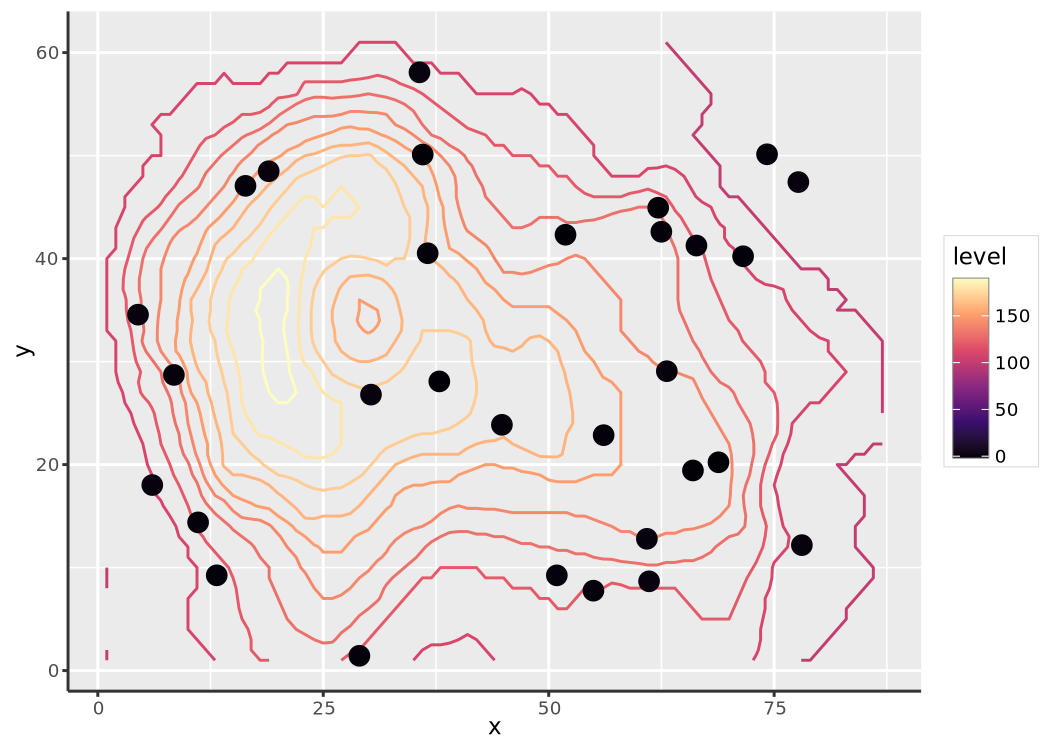

In [3]:
ny, nx = volcano.shape
topography = pd.DataFrame({
    "x": np.tile(np.arange(1, ny + 1), nx),
    "y": np.repeat(np.arange(1, nx + 1), ny),
    "z": volcano.flatten(order="F"),
})

rng = np.random.default_rng(42)
measurements = pd.DataFrame({
    "x": rng.uniform(1, 80, 30),
    "y": rng.uniform(1, 60, 30),
    "thing": rng.standard_normal(30),
})

# Two colour mappings — only the LAST scale_colour_* survives.
(
    gg.ggplot(mapping=gg.aes("x", "y"))
    + gg.geom_contour(data=topography, mapping=gg.aes(z="z", color=gg.after_stat("level")))
    + gg.scale_color_viridis_c(option="D")
    + gg.geom_point(data=measurements, size=3, mapping=gg.aes(color="thing"))
    + gg.scale_color_viridis_c(option="A")  # silently overrides the first scale
)

## 2. `new_scale_color` — the canonical fix

Insert `new_scale_color()` (or `new_scale_colour()`) between the two layers. Everything before it keeps the first colour scale; everything after binds to a fresh one.

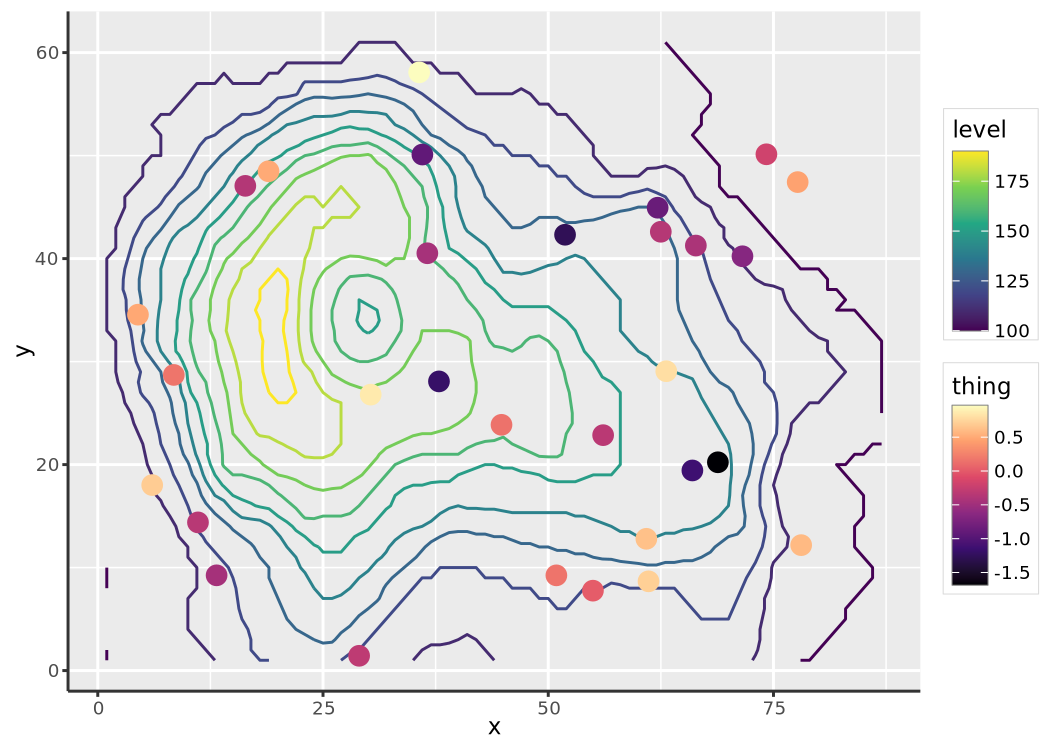

In [4]:
(
    gg.ggplot(mapping=gg.aes("x", "y"))
    + gg.geom_contour(data=topography, mapping=gg.aes(z="z", color=gg.after_stat("level")))
    + gg.scale_color_viridis_c(option="D")   # belongs to the contour layer
    + gns.new_scale_color()                  # ← open a fresh colour slot
    + gg.geom_point(data=measurements, size=3, mapping=gg.aes(color="thing"))
    + gg.scale_color_viridis_c(option="A")   # belongs to the point layer
)

Both legends now render side by side. `new_scale_colour()` is a UK-spelling alias of the same function — `new_scale_color`, `new_scale_colour`, and `new_scale("colour")` produce identical results.

## 3. `new_scale_fill` — same trick, different aesthetic

Heatmap layer with one fill scale, dot overlay with another.

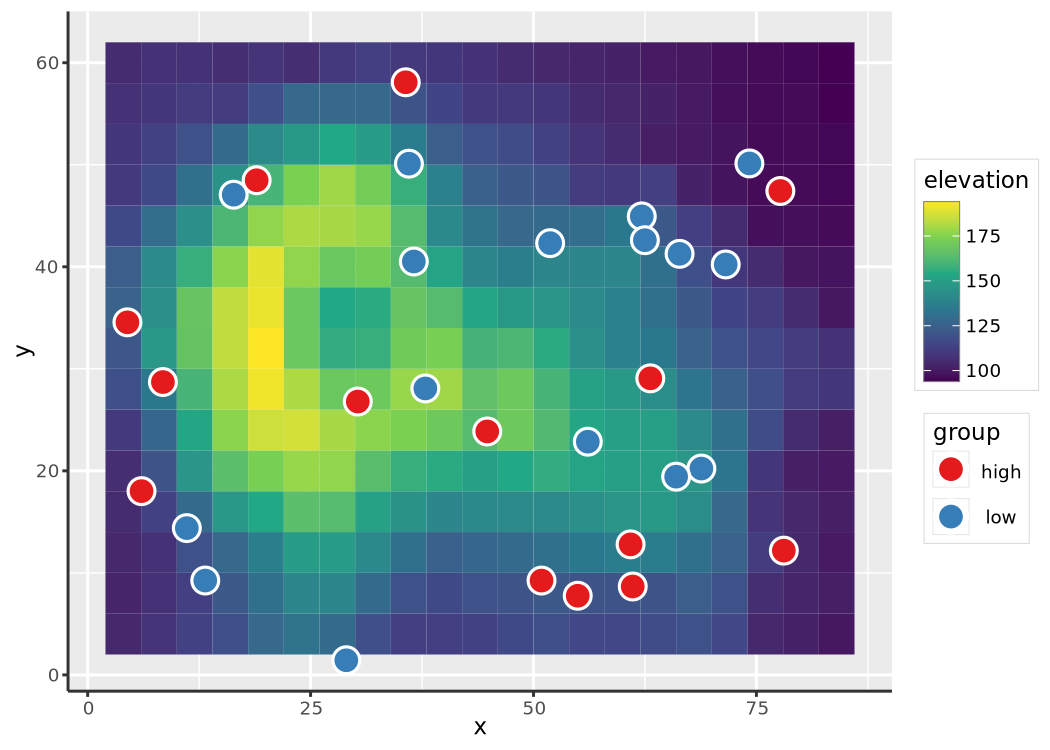

In [5]:
# Coarse grid of tiles drawn from the volcano matrix (subsampled to keep it fast).
step = 4
heat = topography[(topography["x"] % step == 0) & (topography["y"] % step == 0)].copy()

dots = measurements.assign(
    group=pd.Categorical(np.where(measurements["thing"] > 0, "high", "low"))
)

(
    gg.ggplot(mapping=gg.aes("x", "y"))
    + gg.geom_tile(data=heat, mapping=gg.aes(fill="z"), width=step, height=step)
    + gg.scale_fill_viridis_c(option="D", name="elevation")
    + gns.new_scale_fill()                       # ← fresh fill slot
    + gg.geom_point(data=dots, mapping=gg.aes(fill="group"),
                    size=4, shape=21, color="white", stroke=0.8)
    + gg.scale_fill_brewer(palette="Set1", name="group")
)

## 4. `new_scale(any_aesthetic)` — works for `alpha`, `size`, `colour`, `fill`, …

`new_scale("<aes>")` is the generic form. Use it for any aesthetic whose default continuous scale can be constructed without arguments (`colour`, `fill`, `alpha`, `size`). Discrete-only aesthetics like `shape` and `linetype` are not currently supported by the fallback machinery.

Below: two `alpha` mappings, two distinct alpha scales.

/home/groups/xiaojie/nianping/projects/Biobabel/Bio-Babel-public/ggplot2-python/ggplot2_py/scales/__init__.py:2990: UserWarning: Using alpha for a discrete variable is not advised.
  cli_warn("Using alpha for a discrete variable is not advised.")


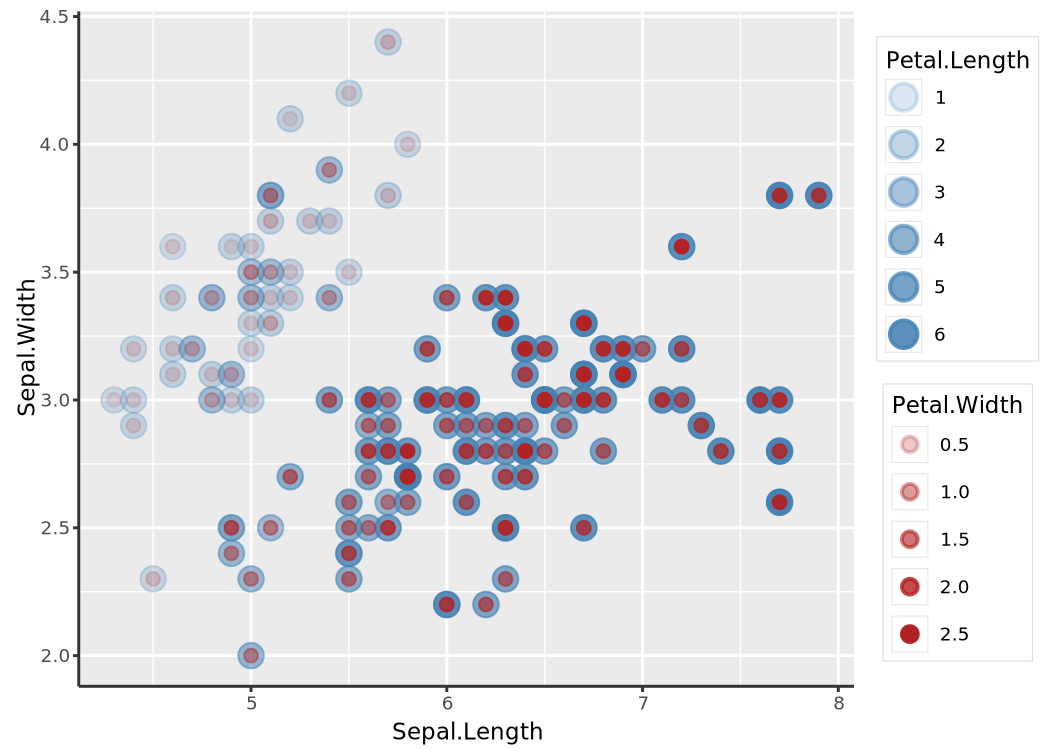

In [6]:
iris2 = iris.copy()

# Two layers, both mapped to `alpha`, with two distinct alpha scales.
(
    gg.ggplot(iris2, gg.aes("Sepal.Length", "Sepal.Width"))
    + gg.geom_point(gg.aes(alpha="Petal.Length"), color="steelblue", size=4)
    + gg.scale_alpha_continuous(range=(0.2, 1.0), name="Petal.Length")
    + gns.new_scale("alpha")
    + gg.geom_point(gg.aes(alpha="Petal.Width"), color="firebrick", size=2)
    + gg.scale_alpha_continuous(range=(0.1, 1.0), name="Petal.Width")
)

## 5. Chaining: more than two scales for the same aesthetic

Call `new_scale_color()` as many times as you have colour scales. Each call opens one more slot.

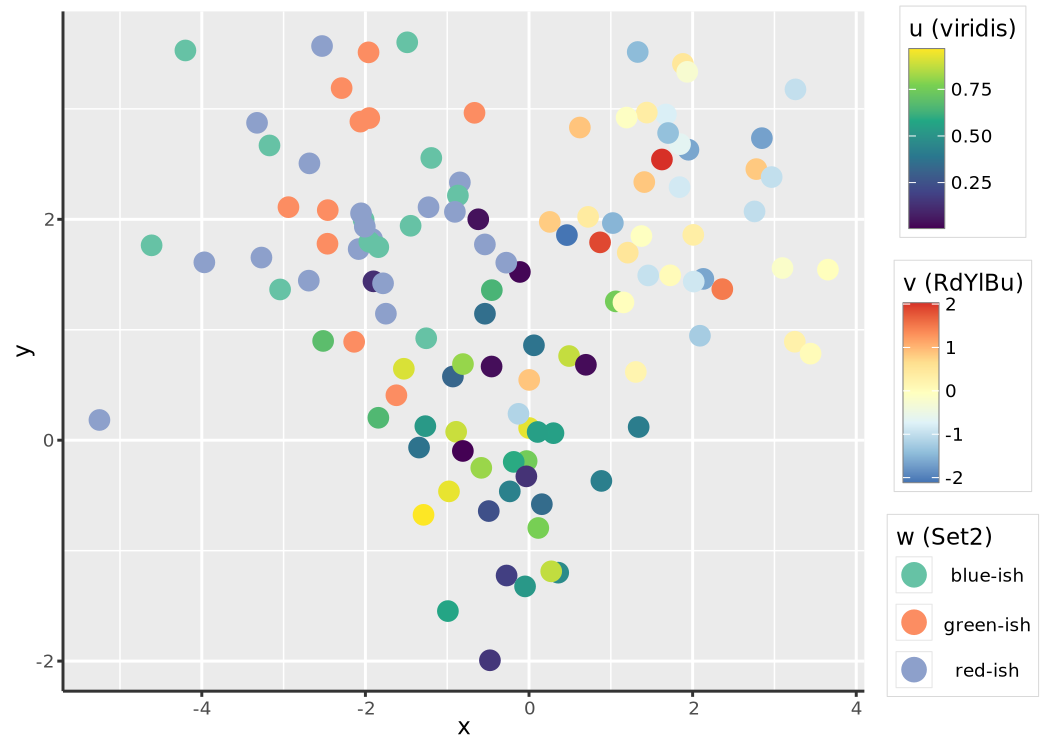

In [7]:
rng2 = np.random.default_rng(7)
n = 40
layer_a = pd.DataFrame({"x": rng2.normal(0, 1, n), "y": rng2.normal(0, 1, n), "u": rng2.uniform(0, 1, n)})
layer_b = pd.DataFrame({"x": rng2.normal(2, 1, n), "y": rng2.normal(2, 1, n), "v": rng2.standard_normal(n)})
layer_c = pd.DataFrame({"x": rng2.normal(-2, 1, n), "y": rng2.normal(2, 1, n),
                        "w": pd.Categorical(rng2.choice(["red-ish", "green-ish", "blue-ish"], n))})

# Mixing the US and UK spellings — both call the same underlying function.
(
    gg.ggplot(mapping=gg.aes("x", "y"))
    + gg.geom_point(data=layer_a, mapping=gg.aes(color="u"), size=3)
    + gg.scale_color_viridis_c(option="D", name="u (viridis)")
    + gns.new_scale_color()                  # US spelling
    + gg.geom_point(data=layer_b, mapping=gg.aes(color="v"), size=3)
    + gg.scale_color_distiller(palette="RdYlBu", name="v (RdYlBu)")
    + gns.new_scale_colour()                 # UK spelling — identical effect
    + gg.geom_point(data=layer_c, mapping=gg.aes(color="w"), size=3)
    + gg.scale_color_brewer(palette="Set2", name="w (Set2)")
)

## 6. `rename_aes` + `clear_aes` — low-level per-layer rename

`new_scale_*` is the everyday tool. `rename_aes` is the lower-level primitive it builds on: it lets you take an *arbitrary* attribute name on a layer's mapping (e.g. `topo_colour`) and re-route it to a fresh slot of a real aesthetic (e.g. `colour`).

Use it when you want fine-grained control over which layer gets renamed and what the renamed slot is called.

The rename **stays active** until you add `clear_aes()` — every layer added in between will be renamed.

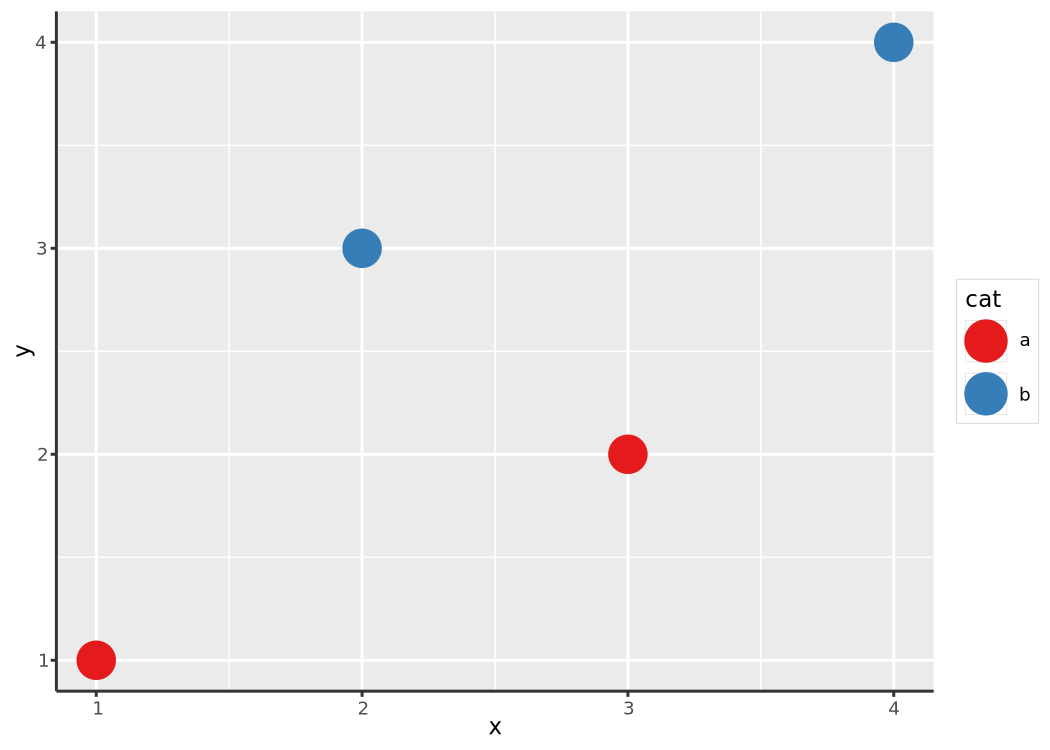

In [8]:
df = pd.DataFrame({"x": [1, 2, 3, 4], "y": [1, 3, 2, 4], "cat": ["a", "b", "a", "b"]})

with warnings.catch_warnings():
    # ggplot2_py rightly warns about the unknown aesthetic name; ggnewscale
    # re-routes it to a real `colour` slot at add-time.
    warnings.simplefilter("ignore", UserWarning)
    g = (
        gg.ggplot(df, gg.aes("x", "y"))
        + gg.geom_point(size=4, color="grey30")          # baseline layer, no rename
        + gns.rename_aes(my_color="color")                # open the rename
        + gg.geom_point(gg.aes(my_color="cat"), size=6)   # renamed → fresh colour scale
        + gg.scale_color_brewer(palette="Set1")
        + gns.clear_aes()                                 # close the rename
    )
g

Inspect the resulting layer to confirm the renamed key is what ggnewscale produced:

In [9]:
renamed_layer = g.layers[1]
print("mapping keys on the renamed layer:", list(renamed_layer.mapping.keys()))

mapping keys on the renamed layer: ['my_colour']


## 7. `register_constructor` / `unregister_constructor` — Python-only

R's `find_global` walks the caller's environment to discover user-defined `scale_<aes>_<type>` and `guide_<name>` constructors. Python has no equivalent built-in mechanism, so this package adds two explicit hooks:

- `register_constructor(name, fn)` — make `fn` discoverable by name
- `unregister_constructor(name)` — undo it

Use these when you have your own `scale_<aes>_*` factories and want ggnewscale's fallback machinery (`assign_scales`) to find them. Below we register a custom `scale_topo_continuous` and then trigger `new_scale("topo")`.

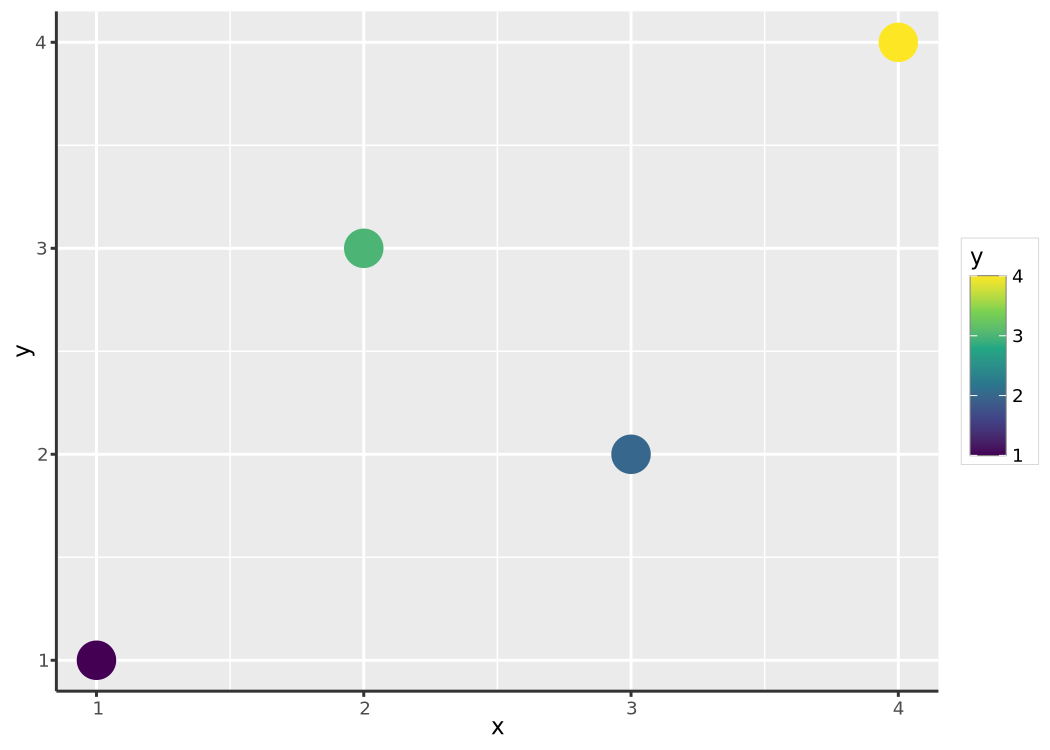

In [10]:
def scale_topo_continuous(**kwargs):
    # A user-defined scale constructor — internally just wraps an existing
    # ggplot2_py colour scale. ggnewscale only needs `name` to find it.
    return gg.scale_colour_viridis_c(aesthetics=[kwargs.get("aesthetics", "topo")])

gns.register_constructor("scale_topo_continuous", scale_topo_continuous)

# Driving example: rename a colour column to `topo`, then open a new
# `topo` slot — assign_scales will look up our user-defined constructor.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    g = (
        gg.ggplot(df, gg.aes("x", "y"))
        + gns.rename_aes(topo="color")
        + gg.geom_point(gg.aes(topo="y"), size=6)
        + gns.new_scale("topo")
    )

gns.unregister_constructor("scale_topo_continuous")
g

## 8. Marker classes — `NewAes`, `RenameNext`, `ClearAes`

Each of the six R-API functions above returns an instance of a small dispatch-tag class. Most users never need to import these — they exist for advanced users who want to construct markers in their own helpers.

In [11]:
print("new_scale_color() ->", repr(gns.new_scale_color()))
print("new_scale_fill()  ->", repr(gns.new_scale_fill()))
print("rename_aes(a='b') ->", repr(gns.rename_aes(a="b")))
print("clear_aes()       ->", repr(gns.clear_aes()))
print()
print("Types:")
print("  NewAes     =", gns.NewAes)
print("  RenameNext =", gns.RenameNext)
print("  ClearAes   =", gns.ClearAes)

new_scale_color() -> NewAes(aes_name='colour')
new_scale_fill()  -> NewAes(aes_name='fill')
rename_aes(a='b') -> RenameNext(mapping={'a': 'b'})
clear_aes()       -> ClearAes()

Types:
  NewAes     = <class 'ggnewscale._markers.NewAes'>
  RenameNext = <class 'ggnewscale._markers.RenameNext'>
  ClearAes   = <class 'ggnewscale._markers.ClearAes'>


---

## Recap

- `new_scale_color()`, `new_scale_fill()`, `new_scale("<aes>")` — 90% of usage
- `rename_aes(...) … clear_aes()` — when you need to bump a non-standard aesthetic name
- `register_constructor(name, fn)` — Python-only escape hatch when you ship your own scale factories

For the full API signatures see the [API reference](../api.html).